# DiffTMM — Inverse Design via Differentiable Optimization

This notebook demonstrates **gradient-based recovery of unknown film thicknesses** using PyTorch autograd through the Transfer Matrix Method.

**Workflow:**
1. Define a "ground truth" film stack with known thicknesses → compute target Fresnel coefficients
2. Initialize a new stack with random thicknesses → optimize with Adam to match the target

**Film stack:** Air | Ta₂O₅ | SiO₂ | Ta₂O₅ | SiO₂ | Ta₂O₅ | Glass (5 optimizable layers)

## 0 · Imports & setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from film_solver_isotropic import create_jones_matrix_isotropic, IsotropicFilmSolver

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print(f"Device: {device}")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

Device: cpu


## 1 · Film stack & forward TMM function

In [2]:
# Film stack: Air(1.0) | Ta2O5 | SiO2 | Ta2O5 | SiO2 | Ta2O5 | Glass(1.52)
n_in  = 1.00   # air
n_out = 1.52   # glass substrate
n_list = torch.tensor([2.10, 1.46, 2.10, 1.46, 2.10], device=device)  # 5 layers
layer_names = ["Ta₂O₅", "SiO₂", "Ta₂O₅", "SiO₂", "Ta₂O₅"]

# Ground truth thicknesses (µm)
d_gt = torch.tensor([0.060, 0.130, 0.085, 0.110, 0.070], device=device)

print("Film stack: Air | " + " | ".join(layer_names) + " | Glass")
print(f"n_list: {n_list.tolist()}")
print(f"GT thicknesses (nm): {(d_gt * 1000).tolist()}")


def forward_tmm(n_list, d_list, n_in, n_out, inp):
    """TMM forward pass for (B, 2) input [wvln_um, angle_rad] → (B, 4) complex [ts, tp, rs, rp]."""
    B = inp.shape[0]
    wvlns  = inp[:, 0]
    angles = inp[:, 1]
    n_layers_1d = n_list.unsqueeze(0).expand(B, -1).to(torch.complex64).to(inp.device)
    d_1d        = d_list.unsqueeze(0).expand(B, -1).to(inp.device)
    ts, tp, rs, rp = create_jones_matrix_isotropic(
        n_layers_1d, d_1d, wvlns.unsqueeze(1), n_in, n_out, angles.unsqueeze(1)
    )
    return torch.stack([ts[:, 0, 0], tp[:, 0, 0], rs[:, 0, 0], rp[:, 0, 0]], dim=-1)

Film stack: Air | Ta₂O₅ | SiO₂ | Ta₂O₅ | SiO₂ | Ta₂O₅ | Glass
n_list: [2.0999999046325684, 1.4600000381469727, 2.0999999046325684, 1.4600000381469727, 2.0999999046325684]
GT thicknesses (nm): [60.0, 130.0, 85.0, 110.0, 70.0]


### Film stack diagram

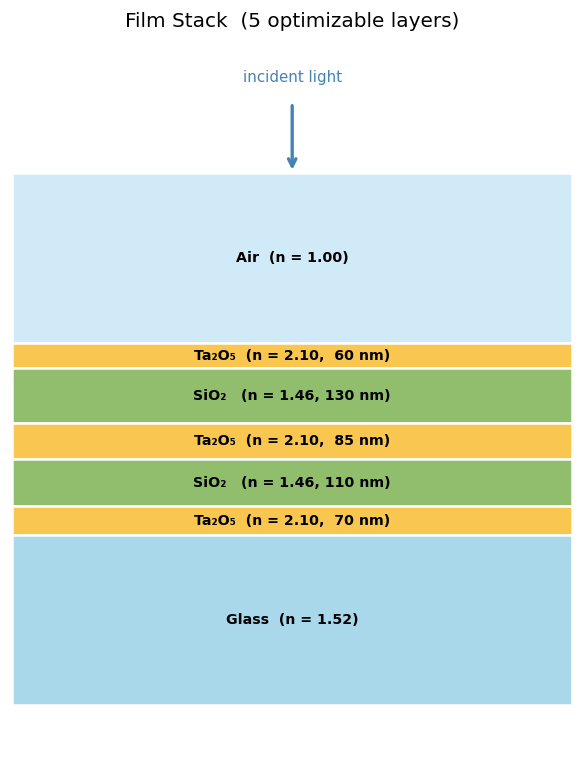

In [3]:
fig, ax = plt.subplots(figsize=(5, 6.5))

# (label, thickness_nm, color)
layers_diag = [
    ("Air  (n = 1.00)",             400, "#d0eaf8"),
    ("Ta₂O₅  (n = 2.10,  60 nm)",   60, "#f9c74f"),
    ("SiO₂   (n = 1.46, 130 nm)",  130, "#90be6d"),
    ("Ta₂O₅  (n = 2.10,  85 nm)",   85, "#f9c74f"),
    ("SiO₂   (n = 1.46, 110 nm)",  110, "#90be6d"),
    ("Ta₂O₅  (n = 2.10,  70 nm)",   70, "#f9c74f"),
    ("Glass  (n = 1.52)",           400, "#a8d8ea"),
]
scale = 4.5 / sum(l[1] for l in layers_diag)

y = 4.5
for label, th_nm, color in layers_diag:
    h = th_nm * scale
    ax.add_patch(plt.Rectangle((0, y - h), 1, h, color=color, ec="white", lw=1.5))
    ax.text(0.5, y - h / 2, label, ha="center", va="center", fontsize=8.5, fontweight="bold")
    y -= h

ax.annotate("", xy=(0.5, 4.5), xytext=(0.5, 5.1),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.text(0.5, 5.25, "incident light", ha="center", va="bottom", fontsize=9, color="steelblue")

ax.set_xlim(0, 1)
ax.set_ylim(-0.4, 5.6)
ax.axis("off")
ax.set_title("Film Stack  (5 optimizable layers)", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## 2 · Generate target data from ground truth stack

In [4]:
B = 1024
torch.manual_seed(42)
wavelengths = torch.lerp(
    torch.full((B,), 0.40, device=device),
    torch.full((B,), 0.70, device=device),
    torch.rand(B, device=device),
)
angles = torch.rand(B, device=device) * (torch.pi / 3)  # 0–60°
inp = torch.stack([wavelengths, angles], dim=-1)  # (B, 2)

with torch.no_grad():
    target = forward_tmm(n_list, d_gt, n_in, n_out, inp)  # (B, 4) complex

print(f"Sampled {B} random (wavelength, angle) pairs")
print(f"Wavelength range: {wavelengths.min().item()*1e3:.0f}–{wavelengths.max().item()*1e3:.0f} nm")
print(f"Angle range:      {angles.min().item()*180/torch.pi:.1f}°–{angles.max().item()*180/torch.pi:.1f}°")
print(f"Target shape: {target.shape}  (complex Fresnel coefficients [ts, tp, rs, rp])")

Sampled 1024 random (wavelength, angle) pairs
Wavelength range: 401–700 nm
Angle range:      0.2°–60.0°
Target shape: torch.Size([1024, 4])  (complex Fresnel coefficients [ts, tp, rs, rp])


### Visualise target data distribution

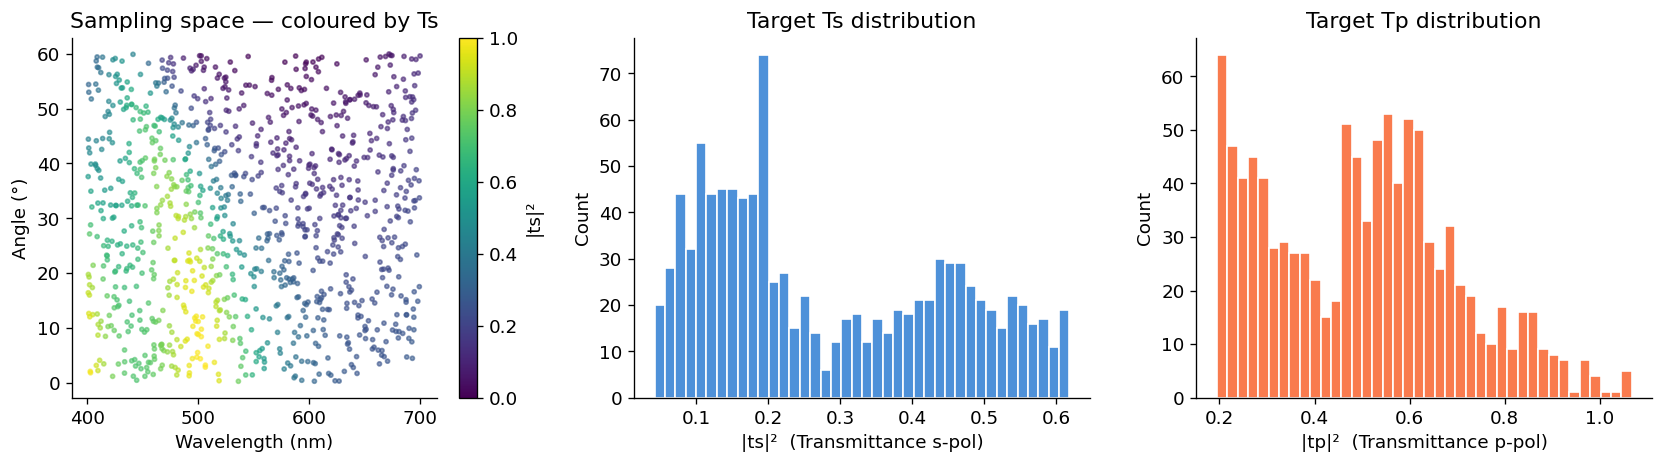

In [5]:
wv_nm = wavelengths.cpu().numpy() * 1000
ang_deg = angles.cpu().numpy() * 180 / np.pi
Ts_tgt = target[:, 0].abs().cpu().numpy() ** 2
Tp_tgt = target[:, 1].abs().cpu().numpy() ** 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Input sample distribution
axes[0].scatter(wv_nm, ang_deg, c=Ts_tgt, cmap="viridis", s=6, alpha=0.6)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=axes[0], label="|ts|²")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Angle (°)")
axes[0].set_title("Sampling space — coloured by Ts")

# Ts distribution histogram
axes[1].hist(Ts_tgt, bins=40, color="#4e91d9", edgecolor="white", lw=0.4)
axes[1].set_xlabel("|ts|²  (Transmittance s-pol)")
axes[1].set_ylabel("Count")
axes[1].set_title("Target Ts distribution")

# Tp distribution histogram
axes[2].hist(Tp_tgt, bins=40, color="#f97b4e", edgecolor="white", lw=0.4)
axes[2].set_xlabel("|tp|²  (Transmittance p-pol)")
axes[2].set_ylabel("Count")
axes[2].set_title("Target Tp distribution")

plt.tight_layout()
plt.show()

## 3 · Optimization loop

Start from random thicknesses and use Adam + cosine LR annealing to recover the ground truth.

In [6]:
d_min, d_max = 0.01, 0.20  # thickness bounds in µm

def param_to_thickness(p):
    return torch.sigmoid(p) * (d_max - d_min) + d_min

torch.manual_seed(42)
d_param = torch.nn.Parameter(torch.randn(5, device=device) * 0.5)
optimizer = torch.optim.Adam([d_param], lr=0.02)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3000)

d_init_nm = (param_to_thickness(d_param.data) * 1000).tolist()
print(f"Initial thicknesses (nm): {[f'{x:.1f}' for x in d_init_nm]}")
print(f"Ground truth      (nm): {[f'{x:.1f}' for x in (d_gt * 1000).tolist()]}")
print()

# Run optimization — record loss & thickness trajectory
loss_history = []
thickness_history = []   # list of (5,) arrays

n_steps = 3000
for step in range(1, n_steps + 1):
    optimizer.zero_grad()
    d_current = param_to_thickness(d_param)
    pred = forward_tmm(n_list, d_current, n_in, n_out, inp)
    diff = pred - target
    loss = (diff.real ** 2 + diff.imag ** 2).mean()
    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())
    if step % 50 == 0:
        thickness_history.append((step, d_current.detach().cpu().numpy() * 1000))

    if step % 500 == 0 or step == 1:
        d_nm = (d_current.detach() * 1000).tolist()
        print(f"Step {step:4d}  loss={loss.item():.3e}  d(nm)=[{', '.join(f'{x:.1f}' for x in d_nm)}]")

d_final = param_to_thickness(d_param.data)

Initial thicknesses (nm): ['113.0', '108.1', '110.6', '110.5', '79.0']
Ground truth      (nm): ['60.0', '130.0', '85.0', '110.0', '70.0']

Step    1  loss=5.794e-01  d(nm)=[113.0, 108.1, 110.6, 110.5, 79.0]


KeyboardInterrupt: 

### Loss curve & thickness trajectory

In [ ]:
steps_th = [s for s, _ in thickness_history]
d_traj   = np.array([d for _, d in thickness_history])  # (T, 5)
d_gt_nm  = (d_gt * 1000).cpu().numpy()

layer_colors = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d", "#9b5de5"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve (log scale)
axes[0].semilogy(np.arange(1, n_steps + 1), loss_history, color="#333333", lw=1.5)
axes[0].set_xlabel("Optimization step")
axes[0].set_ylabel("Loss  (MSE on complex Fresnel)")
axes[0].set_title("Training loss")

# Thickness trajectories vs. ground truth
for i in range(5):
    axes[1].plot(steps_th, d_traj[:, i], color=layer_colors[i], lw=1.8,
                 label=f"Layer {i+1} ({layer_names[i]})")
    axes[1].axhline(d_gt_nm[i], color=layer_colors[i], lw=1, ls="--", alpha=0.6)

axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("Thickness (nm)")
axes[1].set_title("Thickness trajectories  (dashed = ground truth)")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 4 · Results: recovered vs. ground truth thicknesses

In [ ]:
d_final_nm = (d_final * 1000).cpu().numpy()
errors_nm  = np.abs(d_gt_nm - d_final_nm)

print(f"{'Layer':<8} {'Material':<10} {'GT (nm)':>10} {'Recovered (nm)':>16} {'Error (nm)':>12}")
print("  " + "-" * 58)
for i in range(5):
    print(f"  {i+1:<6} {layer_names[i]:<10} {d_gt_nm[i]:10.2f} {d_final_nm[i]:16.2f} {errors_nm[i]:12.3f}")

with torch.no_grad():
    pred_final = forward_tmm(n_list, d_final, n_in, n_out, inp)
    mse = ((pred_final - target).abs() ** 2).mean().item()
print(f"\nFinal MSE on Fresnel coefficients: {mse:.2e}")

# Bar chart comparison
x = np.arange(5)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
bars_gt  = ax.bar(x - w/2, d_gt_nm,    w, label="Ground truth", color="#4e91d9", alpha=0.9)
bars_rec = ax.bar(x + w/2, d_final_nm, w, label="Recovered",    color="#f97b4e", alpha=0.9)

for bar, err in zip(bars_rec, errors_nm):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{err:.2f}", ha="center", va="bottom", fontsize=8, color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels([f"L{i+1}\n{layer_names[i]}" for i in range(5)])
ax.set_ylabel("Thickness (nm)")
ax.set_title("Recovered vs. Ground Truth Thicknesses  (red = error in nm)")
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Spectral comparison: GT vs. recovered stack

Verify the recovered stack produces the same spectral response as the ground truth at normal incidence.

In [ ]:
N_wv = 300
wv_sweep = torch.linspace(0.38, 0.72, N_wv).tolist()
wv_sweep_nm = np.linspace(380, 720, N_wv)
angle_normal = torch.tensor([0.0], device=device)

solver_gt  = IsotropicFilmSolver(n_in=n_in, n_out=n_out, n_layers_list=n_list.tolist(),
                                  d_layers=(d_gt * 1).tolist(), n_mirrors=1, device=device)
solver_rec = IsotropicFilmSolver(n_in=n_in, n_out=n_out, n_layers_list=n_list.tolist(),
                                  d_layers=d_final.tolist(), n_mirrors=1, device=device)

with torch.no_grad():
    ts_gt,  tp_gt,  rs_gt,  rp_gt  = solver_gt.simulate(theta=angle_normal,  wvln=wv_sweep)
    ts_rec, tp_rec, rs_rec, rp_rec = solver_rec.simulate(theta=angle_normal, wvln=wv_sweep)

Ts_gt  = (ts_gt[0, :, 0].abs() ** 2).cpu().numpy()
Ts_rec = (ts_rec[0, :, 0].abs() ** 2).cpu().numpy()
Rs_gt  = (rs_gt[0, :, 0].abs() ** 2).cpu().numpy()
Rs_rec = (rs_rec[0, :, 0].abs() ** 2).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(wv_sweep_nm, Ts_gt,  color="#4e91d9", lw=2,   label="Ground truth")
axes[0].plot(wv_sweep_nm, Ts_rec, color="#f97b4e", lw=1.5, ls="--", label="Recovered")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Transmittance  |ts|²")
axes[0].set_title("Transmittance (s-pol, normal incidence)")
axes[0].legend()
axes[0].set_xlim(380, 720)

axes[1].plot(wv_sweep_nm, Rs_gt,  color="#4e91d9", lw=2,   label="Ground truth")
axes[1].plot(wv_sweep_nm, Rs_rec, color="#f97b4e", lw=1.5, ls="--", label="Recovered")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Reflectance  |rs|²")
axes[1].set_title("Reflectance (s-pol, normal incidence)")
axes[1].legend()
axes[1].set_xlim(380, 720)

fig.suptitle("Spectral Comparison — GT vs. Recovered Stack", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

max_diff_Ts = np.abs(Ts_gt - Ts_rec).max()
max_diff_Rs = np.abs(Rs_gt - Rs_rec).max()
print(f"Max |ΔTs| across spectrum: {max_diff_Ts:.2e}")
print(f"Max |ΔRs| across spectrum: {max_diff_Rs:.2e}")